In [1]:
# CELL 1: KIỂM TRA GPU & CÀI ĐẶT THƯ VIỆN

import subprocess
import sys

print("="*70)
print("  CELL 1: KIỂM TRA GPU & CÀI ĐẶT THƯ VIỆN")
print("="*70 + "\n")

# ════════════════════════════════════════════════
# KIỂM TRA GPU
# ════════════════════════════════════════════════

import torch

print("🖥️  GPU Check:\n")
print(f"✅ CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ Memory: {mem:.1f} GB")
else:
    print("⚠️  GPU không có sẵn – training sẽ chậm hơn")

print()

# ════════════════════════════════════════════════
# CÀI ĐẶT THƯ VIỆN
# ════════════════════════════════════════════════

print("📦 Cài đặt thư viện...\n")

# Ultralytics (YOLOv8)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])
print("✅ ultralytics (YOLOv8) installed")

# timm – PyTorch Image Models (EfficientNet)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
print("✅ timm (EfficientNet) installed")

# scikit-learn (metrics)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
print("✅ scikit-learn installed")

print("\n✅ CELL 1 DONE")

  CELL 1: KIỂM TRA GPU & CÀI ĐẶT THƯ VIỆN

🖥️  GPU Check:

✅ CUDA available: True
✅ GPU: Tesla T4
✅ Memory: 15.6 GB

📦 Cài đặt thư viện...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.9 MB/s eta 0:00:00
✅ ultralytics (YOLOv8) installed
✅ timm (EfficientNet) installed
✅ scikit-learn installed

✅ CELL 1 DONE


In [2]:
# CELL 2: LOAD DATASET TỪ KAGGLE INPUT

import os
import shutil
import yaml

print("="*70)
print("  CELL 2: LOAD DATASET")
print("="*70 + "\n")

input_dir = '/kaggle/input'
working_dir = '/kaggle/working'

print(f"📂 Input directory: {input_dir}\n")

# ════════════════════════════════════════════════
# LIỆT KÊ DATASETS
# ════════════════════════════════════════════════

print("📋 Available datasets:\n")

dataset_folders = []
for item in os.listdir(input_dir):
    item_path = os.path.join(input_dir, item)
    if os.path.isdir(item_path):
        dataset_folders.append(item)
        print(f"   - {item}")

print()

# ════════════════════════════════════════════════
# TÌM data.yaml
# ════════════════════════════════════════════════

dataset_dir = None
yaml_path = None

for folder in dataset_folders:
    folder_path = os.path.join(input_dir, folder)
    for root, dirs, files in os.walk(folder_path):
        if 'data.yaml' in files:
            yaml_path = os.path.join(root, 'data.yaml')
            dataset_dir = root
            break
    if yaml_path:
        break

if yaml_path:
    print(f"✅ Found data.yaml: {yaml_path}\n")
    with open(yaml_path, 'r') as f:
        data_cfg = yaml.safe_load(f)
    print("Config:")
    for k, v in data_cfg.items():
        print(f"   {k}: {v}")
else:
    print("❌ data.yaml not found!")
    print("   Tạo cấu trúc dataset mặc định...\n")

    # Tạo cấu trúc mặc định
    dataset_dir = os.path.join(working_dir, 'dataset')
    os.makedirs(os.path.join(dataset_dir, 'train/images'), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, 'train/labels'), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, 'valid/images'), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, 'valid/labels'), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, 'test/images'), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, 'test/labels'), exist_ok=True)

    yaml_content = {
        'path': dataset_dir,
        'train': 'train/images',
        'val': 'valid/images',
        'test': 'test/images',
        'nc': 9,
        'names': ['100k', '10k', '1k', '200k', '20k', '2k', '500k', '50k', '5k']
    }

    yaml_path = os.path.join(dataset_dir, 'data.yaml')
    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_content, f)

    print(f"✅ Created default data.yaml: {yaml_path}")

print("\n✅ CELL 2 DONE")

  CELL 2: LOAD DATASET

📂 Input directory: /kaggle/input

📋 Available datasets:

   - datasets
   - models

✅ Found data.yaml: /kaggle/input/datasets/phantrnhuduy/tiendataset-full/data.yaml

Config:
   train: ../train/images
   val: ../valid/images
   test: ../test/images
   nc: 9
   names: ['100k', '10k', '1k', '200k', '20k', '2k', '500k', '50k', '5k']
   roboflow: {'workspace': 'duys-workspace-aug5v', 'project': 'duys-workspace-aug5v', 'version': 'dataset', 'license': 'Private', 'url': 'https://app.roboflow.com/duys-workspace-aug5v/duys-workspace-aug5v/dataset'}

✅ CELL 2 DONE


In [3]:
# CELL 3: CHUẨN BỊ DỮ LIỆU YOLO

import os
import yaml
import shutil

print("="*70)
print("  CELL 3: CHUẨN BỊ DỮ LIỆU YOLO")
print("="*70 + "\n")

working_dataset = '/kaggle/working/dataset'
os.makedirs(working_dataset, exist_ok=True)

# ════════════════════════════════════════════════
# SAO CHÉP DATASET VÀO WORKING
# ════════════════════════════════════════════════

print("📋 Kiểm tra splits:\n")

stats = {}
for split in ['train', 'valid', 'val', 'test']:
    img_dir = os.path.join(working_dataset, split, 'images')
    lbl_dir = os.path.join(working_dataset, split, 'labels')
    if os.path.exists(img_dir):
        n_img = len([f for f in os.listdir(img_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        n_lbl = len([f for f in os.listdir(lbl_dir)
                     if f.endswith('.txt')]) if os.path.exists(lbl_dir) else 0
        if n_img > 0:
            stats[split] = (n_img, n_lbl)
            print(f"   {split}: {n_img} images, {n_lbl} labels")

print()

# Nếu chưa có dữ liệu – sao chép từ input
if not stats:
    print("📂 Sao chép từ Kaggle input...\n")
    if dataset_dir and os.path.exists(dataset_dir):
        for split in ['train', 'valid', 'val', 'test']:
            src = os.path.join(dataset_dir, split)
            dst = os.path.join(working_dataset, split)
            if os.path.exists(src):
                shutil.copytree(src, dst, dirs_exist_ok=True)
                n_img = len(list(os.listdir(os.path.join(dst, 'images'))))
                print(f"   ✅ {split}: {n_img} images")
    else:
        print("   ⚠️  Không tìm thấy dataset input – hãy upload dataset trước")

# ════════════════════════════════════════════════
# CẬP NHẬT data.yaml
# ════════════════════════════════════════════════

print("\n📝 Cập nhật data.yaml...\n")

# Xác định tên val split
val_split = 'valid' if os.path.exists(os.path.join(working_dataset, 'valid', 'images')) else 'val'

yaml_content = {
    'path': working_dataset,
    'train': 'train/images',
    'val': f'{val_split}/images',
    'test': 'test/images',
    'nc': 9,
    'names': ['100k', '10k', '1k', '200k', '20k', '2k', '500k', '50k', '5k']
}

final_yaml = os.path.join(working_dataset, 'data.yaml')
with open(final_yaml, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print(f"✅ data.yaml saved: {final_yaml}")
print(f"   path: {working_dataset}")
print(f"   train: train/images")
print(f"   val: {val_split}/images")
print(f"   nc: 9")

print("\n✅ CELL 3 DONE")


  CELL 3: CHUẨN BỊ DỮ LIỆU YOLO

📋 Kiểm tra splits:


📂 Sao chép từ Kaggle input...

   ✅ train: 7714 images

📝 Cập nhật data.yaml...

✅ data.yaml saved: /kaggle/working/dataset/data.yaml
   path: /kaggle/working/dataset
   train: train/images
   val: val/images
   nc: 9

✅ CELL 3 DONE


In [4]:
# CELL 3.5: TỰ ĐỘNG TÁCH train → train / val / test (70/15/15)

import os, shutil, random, yaml
from pathlib import Path

working_dataset = '/kaggle/working/dataset'
yaml_path = os.path.join(working_dataset, 'data.yaml')

# ════════════════════════════════════════════════
# KIỂM TRA DỮ LIỆU HIỆN TẠI
# ════════════════════════════════════════════════

train_img_dir = os.path.join(working_dataset, 'train', 'images')
train_lbl_dir = os.path.join(working_dataset, 'train', 'labels')

all_imgs = [f for f in os.listdir(train_img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"📂 Tổng ảnh trong train: {len(all_imgs)}")

if len(all_imgs) < 10:
    raise ValueError("❌ Quá ít ảnh để tách! Kiểm tra lại dataset.")

# ════════════════════════════════════════════════
# CHIA TỈ LỆ  70 / 15 / 15
# ════════════════════════════════════════════════

random.seed(42)
random.shuffle(all_imgs)

n_total = len(all_imgs)
n_val   = max(1, int(n_total * 0.15))
n_test  = max(1, int(n_total * 0.15))
n_train = n_total - n_val - n_test

split_train = all_imgs[:n_train]
split_val   = all_imgs[n_train:n_train + n_val]
split_test  = all_imgs[n_train + n_val:]

print(f"   Train : {len(split_train)} ảnh  (70%)")
print(f"   Val   : {len(split_val)} ảnh  (15%)")
print(f"   Test  : {len(split_test)} ảnh  (15%)\n")

# ════════════════════════════════════════════════
# SAO CHÉP FILE VÀO THƯ MỤC MỚI
# ════════════════════════════════════════════════

def copy_split(file_list, src_img, src_lbl, dst_split):
    dst_img = os.path.join(working_dataset, dst_split, 'images')
    dst_lbl = os.path.join(working_dataset, dst_split, 'labels')
    os.makedirs(dst_img, exist_ok=True)
    os.makedirs(dst_lbl, exist_ok=True)

    missing_lbl = 0
    for fname in file_list:
        shutil.copy2(os.path.join(src_img, fname),
                     os.path.join(dst_img, fname))
        lbl_name = Path(fname).stem + '.txt'
        lbl_src  = os.path.join(src_lbl, lbl_name)
        if os.path.exists(lbl_src):
            shutil.copy2(lbl_src, os.path.join(dst_lbl, lbl_name))
        else:
            missing_lbl += 1

    print(f"✅ {dst_split}: {len(file_list)} ảnh"
          + (f"  ⚠️  {missing_lbl} ảnh thiếu label" if missing_lbl else ""))

# Tạo thư mục tạm tránh ghi đè chính nó
tmp_dir = os.path.join(working_dataset, '_tmp_train')
shutil.copytree(os.path.join(working_dataset, 'train'), tmp_dir)

src_img = os.path.join(tmp_dir, 'images')
src_lbl = os.path.join(tmp_dir, 'labels')

shutil.rmtree(os.path.join(working_dataset, 'train'))

copy_split(split_train, src_img, src_lbl, 'train')
copy_split(split_val,   src_img, src_lbl, 'valid')
copy_split(split_test,  src_img, src_lbl, 'test')

shutil.rmtree(tmp_dir)

# ════════════════════════════════════════════════
# GHI data.yaml
# ════════════════════════════════════════════════

data_cfg = {
    'path'  : working_dataset,
    'train' : 'train/images',
    'val'   : 'valid/images',
    'test'  : 'test/images',
    'nc'    : 9,
    'names' : ['100k', '10k', '1k', '200k', '20k', '2k', '500k', '50k', '5k'],
}

with open(yaml_path, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False, allow_unicode=True)

print(f"\n📄 data.yaml đã cập nhật:")
with open(yaml_path) as f:
    print(f.read())

print("✅ CELL 3.5 DONE – Chạy lại Cell 4 để training!")

📂 Tổng ảnh trong train: 7714
   Train : 5400 ảnh  (70%)
   Val   : 1157 ảnh  (15%)
   Test  : 1157 ảnh  (15%)

✅ train: 5400 ảnh
✅ valid: 1157 ảnh
✅ test: 1157 ảnh

📄 data.yaml đã cập nhật:
names:
- 100k
- 10k
- 1k
- 200k
- 20k
- 2k
- 500k
- 50k
- 5k
nc: 9
path: /kaggle/working/dataset
test: test/images
train: train/images
val: valid/images

✅ CELL 3.5 DONE – Chạy lại Cell 4 để training!


In [8]:
# CELL 4: HUẤN LUYỆN YOLO (Stage 1 – Detection)

from ultralytics import YOLO
import torch, os, glob

print("="*70)
print("  CELL 4: HUẤN LUYỆN YOLOv8 – STAGE 1 DETECTION")
print("="*70 + "\n")

working_dataset = '/kaggle/working/dataset'
yaml_path = os.path.join(working_dataset, 'data.yaml')

# ════════════════════════════════════════════════
# HYPERPARAMETERS
# ════════════════════════════════════════════════

YOLO_EPOCHS   = 100
YOLO_BATCH    = 16
YOLO_IMGSZ    = 640
YOLO_LR0      = 0.001
YOLO_LRF      = 0.0001
YOLO_PATIENCE = 20

# ════════════════════════════════════════════════
# LOAD MODEL  ← CHỈ SỬA PHẦN NÀY
# ════════════════════════════════════════════════

print("📥 Khởi tạo YOLOv8s...\n")

# Không có pre-trained custom → dùng thẳng yolov8s.pt (COCO)
yolo_model = YOLO('yolov8s.pt')
print("✅ Loaded YOLOv8s (COCO pretrained – sẽ tự download nếu chưa có)")

total_params = sum(p.numel() for p in yolo_model.model.parameters())
print(f"   Parameters: {total_params:,}\n")

# ════════════════════════════════════════════════
# CẤU HÌNH TRAINING
# ════════════════════════════════════════════════

print("⚙️  Training config:\n")

yolo_config = {
    'data'          : yaml_path,
    'epochs'        : YOLO_EPOCHS,
    'batch'         : YOLO_BATCH,
    'imgsz'         : YOLO_IMGSZ,
    'device'        : 0 if torch.cuda.is_available() else 'cpu',
    'optimizer'     : 'AdamW',
    'lr0'           : YOLO_LR0,
    'lrf'           : YOLO_LRF,
    'warmup_epochs' : 3,
    'weight_decay'  : 0.0005,
    'patience'      : YOLO_PATIENCE,
    'save'          : True,
    'project'       : '/kaggle/working/runs/yolo',
    'name'          : 'train',
    'verbose'       : True,
}

for k, v in list(yolo_config.items())[:8]:
    print(f"   {k}: {v}")
print("   ...\n")

# ════════════════════════════════════════════════
# TRAINING
# ════════════════════════════════════════════════

torch.cuda.empty_cache()
print("🚀 Bắt đầu training YOLO...\n")

yolo_results = yolo_model.train(**yolo_config)

print("\n" + "="*70)
print("  ✅ YOLO TRAINING HOÀN THÀNH!")
print("="*70 + "\n")

try:
    print("📊 YOLO Metrics:")
    print(f"   mAP50:     {yolo_results.box.map50:.4f}")
    print(f"   mAP50-95:  {yolo_results.box.map:.4f}")
    print(f"   Precision: {yolo_results.box.mp:.4f}")
    print(f"   Recall:    {yolo_results.box.mr:.4f}")
except Exception as e:
    print(f"   (Xem logs training) - {e}")

# ← SỬA BUG: fallback về pretrained_path không tồn tại
best_models = glob.glob('/kaggle/working/runs/yolo/train*/weights/best.pt')
if best_models:
    yolo_best_path = sorted(best_models)[-1]
else:
    raise FileNotFoundError("❌ Không tìm thấy best.pt sau training! Kiểm tra lại logs.")

print(f"\n💾 YOLO best model: {yolo_best_path}")
print("\n✅ CELL 4 DONE")

  CELL 4: HUẤN LUYỆN YOLOv8 – STAGE 1 DETECTION

📥 Khởi tạo YOLOv8s...

✅ Loaded YOLOv8s (COCO pretrained – sẽ tự download nếu chưa có)
   Parameters: 11,166,560

⚙️  Training config:

   data: /kaggle/working/dataset/data.yaml
   epochs: 100
   batch: 16
   imgsz: 640
   device: 0
   optimizer: AdamW
   lr0: 0.001
   lrf: 0.0001
   ...

🚀 Bắt đầu training YOLO...

Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, h

In [10]:
# CELL 4.5: LƯU YOLO MODEL SAU TRAINING

import os, shutil, glob
#from google.colab import files  # bỏ dòng này nếu dùng Kaggle

print("="*70)
print("  CELL 4.5: LƯU YOLO MODEL")
print("="*70 + "\n")

# ════════════════════════════════════════════════
# TÌM FILE BEST.PT VỪA TRAIN
# ════════════════════════════════════════════════

best_models = glob.glob('/kaggle/working/runs/yolo/train*/weights/best.pt')
last_models = glob.glob('/kaggle/working/runs/yolo/train*/weights/last.pt')

if not best_models:
    raise FileNotFoundError("❌ Không tìm thấy best.pt! Kiểm tra Cell 4 đã chạy thành công chưa.")

yolo_best_path = sorted(best_models)[-1]
yolo_last_path = sorted(last_models)[-1] if last_models else None

print(f"✅ best.pt : {yolo_best_path}")
print(f"✅ last.pt : {yolo_last_path}\n")

# ════════════════════════════════════════════════
# SAO CHÉP VỀ /kaggle/working (dễ tải xuống)
# ════════════════════════════════════════════════

save_dir = '/kaggle/working/saved_models'
os.makedirs(save_dir, exist_ok=True)

best_dst = os.path.join(save_dir, 'yolo_best.pt')
last_dst = os.path.join(save_dir, 'yolo_last.pt')

shutil.copy2(yolo_best_path, best_dst)
print(f"💾 Đã lưu best.pt → {best_dst}")

if yolo_last_path:
    shutil.copy2(yolo_last_path, last_dst)
    print(f"💾 Đã lưu last.pt → {last_dst}")

# ════════════════════════════════════════════════
# IN THÔNG TIN MODEL
# ════════════════════════════════════════════════

size_mb = os.path.getsize(best_dst) / 1e6
print(f"\n📦 Kích thước best.pt : {size_mb:.1f} MB")

# ════════════════════════════════════════════════
# KIỂM TRA MODEL CÓ LOAD ĐƯỢC KHÔNG
# ════════════════════════════════════════════════

from ultralytics import YOLO

print("\n🔍 Kiểm tra load lại model...")
verify_model = YOLO(best_dst)
print(f"✅ Load thành công!")
print(f"   Classes : {verify_model.names}")
print(f"   Task    : {verify_model.task}")

print("\n✅ CELL 4.5 DONE")
print(f"\n📥 Tải về máy: vào Output → saved_models → yolo_best.pt")

  CELL 4.5: LƯU YOLO MODEL

✅ best.pt : /kaggle/working/runs/yolo/train2/weights/best.pt
✅ last.pt : /kaggle/working/runs/yolo/train2/weights/last.pt

💾 Đã lưu best.pt → /kaggle/working/saved_models/yolo_best.pt
💾 Đã lưu last.pt → /kaggle/working/saved_models/yolo_last.pt

📦 Kích thước best.pt : 22.5 MB

🔍 Kiểm tra load lại model...
✅ Load thành công!
   Classes : {0: '100k', 1: '10k', 2: '1k', 3: '200k', 4: '20k', 5: '2k', 6: '500k', 7: '50k', 8: '5k'}
   Task    : detect

✅ CELL 4.5 DONE

📥 Tải về máy: vào Output → saved_models → yolo_best.pt


  CELL 4.6: KIỂM TRA YOLO MODEL

📥 Load model: /kaggle/working/runs/yolo/train2/weights/best.pt

📊 Đánh giá trên tập val...

Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,067 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1602.1±1458.9 MB/s, size: 535.6 KB)
val: Scanning /kaggle/working/dataset/valid/labels.cache... 1157 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1157/1157 346.6Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 571, len(boxes) = 2741. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


/tmp/ipykernel_55/3137825266.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COLORS = plt.cm.get_cmap('tab10', len(CLASS_NAMES))


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 73/73 4.7it/s 15.6s0.2s
                   all       1157       2741      0.985       0.98       0.99      0.924
Speed: 0.9ms preprocess, 9.2ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
   mAP50     : 0.9902
   mAP50-95  : 0.9237
   Precision : 0.9847
   Recall    : 0.9795

   Per-class mAP50:
      100k   : 0.9879
      10k    : 0.9922
      1k     : 0.9903
      200k   : 0.9771
      20k    : 0.9926
      2k     : 0.9885
      500k   : 0.9939
      50k    : 0.9945
      5k     : 0.9947

🖼️  Visualize trên ảnh test ngẫu nhiên...



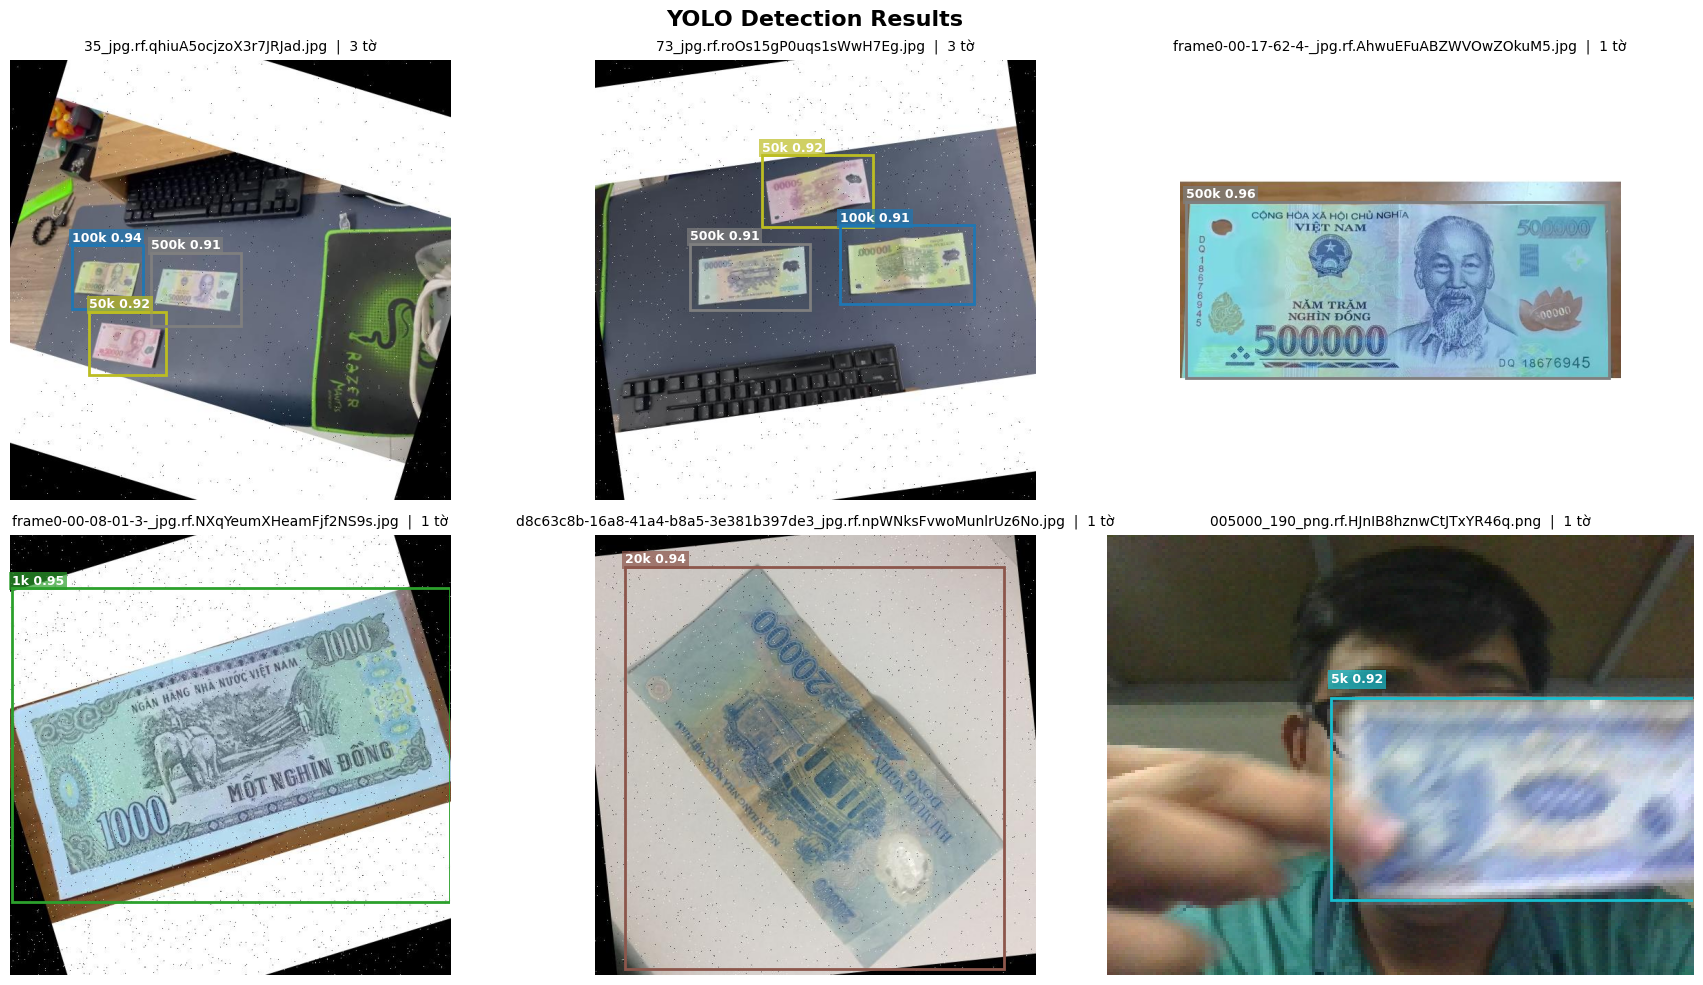

✅ Saved: /kaggle/working/yolo_test_preview.png

📈 Phân phối confidence score trên tập val...



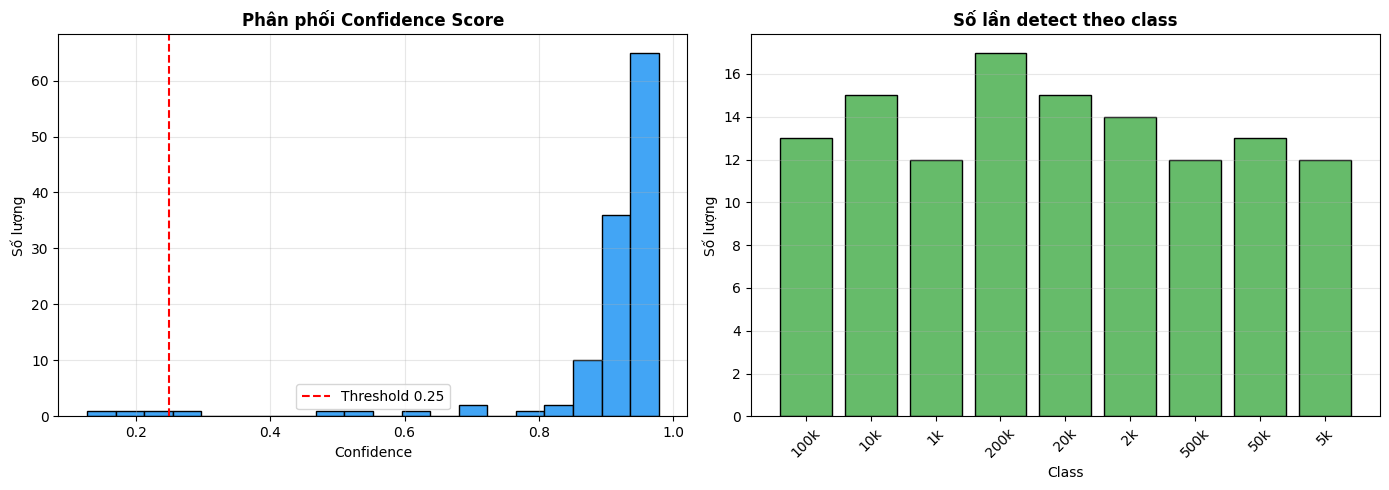

✅ Saved: /kaggle/working/yolo_confidence_stats.png

✅ CELL 4.6 DONE
👉 Nếu mAP50 > 0.85 thì ổn, chạy tiếp Cell 5!


In [11]:
# CELL 4.6: KIỂM TRA YOLO MODEL TRƯỚC KHI TRAIN EFFICIENTNET

import os, cv2, glob, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

print("="*70)
print("  CELL 4.6: KIỂM TRA YOLO MODEL")
print("="*70 + "\n")

CLASS_NAMES = ['100k', '10k', '1k', '200k', '20k', '2k', '500k', '50k', '5k']
COLORS = plt.cm.get_cmap('tab10', len(CLASS_NAMES))

# ════════════════════════════════════════════════
# LOAD MODEL
# ════════════════════════════════════════════════

best_models = glob.glob('/kaggle/working/runs/yolo/train*/weights/best.pt')
yolo_best_path = sorted(best_models)[-1] if best_models else '/kaggle/working/saved_models/yolo_best.pt'

print(f"📥 Load model: {yolo_best_path}\n")
yolo_model = YOLO(yolo_best_path)

# ════════════════════════════════════════════════
# 1. ĐÁNH GIÁ TRÊN TẬP VAL (metrics tổng quan)
# ════════════════════════════════════════════════

print("📊 Đánh giá trên tập val...\n")

val_results = yolo_model.val(
    data='/kaggle/working/dataset/data.yaml',
    split='val',
    verbose=False,
)

print(f"   mAP50     : {val_results.box.map50:.4f}")
print(f"   mAP50-95  : {val_results.box.map:.4f}")
print(f"   Precision : {val_results.box.mp:.4f}")
print(f"   Recall    : {val_results.box.mr:.4f}")

# Per-class mAP50
print("\n   Per-class mAP50:")
for i, name in enumerate(CLASS_NAMES):
    try:
        print(f"      {name:6} : {val_results.box.ap50[i]:.4f}")
    except:
        pass

# ════════════════════════════════════════════════
# 2. VISUALIZE PREDICT TRÊN ẢNH NGẪU NHIÊN
# ════════════════════════════════════════════════

print("\n🖼️  Visualize trên ảnh test ngẫu nhiên...\n")

test_img_dir = '/kaggle/working/dataset/test/images'
if not os.path.exists(test_img_dir):
    test_img_dir = '/kaggle/working/dataset/valid/images'

img_files = [f for f in os.listdir(test_img_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Chọn ngẫu nhiên 6 ảnh
random.seed(99)
samples = random.sample(img_files, min(6, len(img_files)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('YOLO Detection Results', fontsize=16, fontweight='bold')
axes = axes.flatten()

for ax, img_file in zip(axes, samples):
    img_path = os.path.join(test_img_dir, img_file)
    img_bgr  = cv2.imread(img_path)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = yolo_model.predict(
        source=img_path,
        conf=0.25,
        iou=0.45,
        verbose=False,
    )[0]

    ax.imshow(img_rgb)

    for box in results.boxes:
        cls_id  = int(box.cls[0])
        conf    = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color   = COLORS(cls_id)[:3]

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1 - 5,
            f"{CLASS_NAMES[cls_id]} {conf:.2f}",
            color='white', fontsize=9, fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.7, pad=2, edgecolor='none')
        )

    ax.set_title(f"{img_file}  |  {len(results.boxes)} tờ", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/yolo_test_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: /kaggle/working/yolo_test_preview.png")

# ════════════════════════════════════════════════
# 3. THỐNG KÊ CONFIDENCE PHÂN PHỐI
# ════════════════════════════════════════════════

print("\n📈 Phân phối confidence score trên tập val...\n")

all_confs  = []
all_cls    = []

for img_file in img_files[:50]:  # lấy 50 ảnh để thống kê nhanh
    img_path = os.path.join(test_img_dir, img_file)
    res = yolo_model.predict(source=img_path, conf=0.1, verbose=False)[0]
    for box in res.boxes:
        all_confs.append(float(box.conf[0]))
        all_cls.append(int(box.cls[0]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram confidence
axes[0].hist(all_confs, bins=20, color='#42A5F5', edgecolor='black')
axes[0].axvline(x=0.25, color='red', linestyle='--', label='Threshold 0.25')
axes[0].set_title('Phân phối Confidence Score', fontweight='bold')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Số lượng')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Số detection theo class
cls_counts = {name: all_cls.count(i) for i, name in enumerate(CLASS_NAMES)}
axes[1].bar(cls_counts.keys(), cls_counts.values(), color='#66BB6A', edgecolor='black')
axes[1].set_title('Số lần detect theo class', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Số lượng')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/kaggle/working/yolo_confidence_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: /kaggle/working/yolo_confidence_stats.png")

print("\n✅ CELL 4.6 DONE")
print("👉 Nếu mAP50 > 0.85 thì ổn, chạy tiếp Cell 5!")

In [ ]:
##Train EfficientNet tích hợp CBAM

In [1]:
# CELL 1: KIỂM TRA GPU & CÀI THƯ VIỆN

import subprocess, sys, torch

print("="*70)
print("  CELL 1: GPU & CÀI ĐẶT")
print("="*70 + "\n")

print(f"✅ CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU : {torch.cuda.get_device_name(0)}")
    print(f"✅ VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB\n")
else:
    print("❌ Không có GPU! Vào Settings → Accelerator → GPU T4 x2")

print("📦 Cài thư viện...")
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn'])
print("✅ Done\n")
print("✅ CELL 1 DONE")

  CELL 1: GPU & CÀI ĐẶT

✅ CUDA: True
✅ GPU : Tesla T4
✅ VRAM: 15.6 GB

📦 Cài thư viện...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.6 MB/s eta 0:00:00
✅ Done

✅ CELL 1 DONE


In [1]:
import os

YAML_PATH = "/kaggle/input/datasets/phantrnhuduy/tiendataset-full/data.yaml"
ROOT_DIR  = os.path.dirname(YAML_PATH)  # /kaggle/input/datasets/phantrnhuduy/tiendataset-full

print("ROOT_DIR:", ROOT_DIR)
print("Exists:", os.path.exists(ROOT_DIR))

ROOT_DIR: /kaggle/input/datasets/phantrnhuduy/tiendataset-full
Exists: True


In [2]:
import yaml

with open(YAML_PATH, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

print(data_cfg)

# Thường YOLO yaml có:
# train: train/images
# val: val/images (hoặc thiếu)
# names: ['100k','10k',...]
names = data_cfg.get("names", None)
if isinstance(names, dict):
    # dạng {0:'100k',1:'10k',...}
    idx_to_class = {int(k): v for k, v in names.items()}
else:
    # dạng list
    idx_to_class = {i: n for i, n in enumerate(names)}

class_to_idx = {v:k for k,v in idx_to_class.items()}

print("idx_to_class:", idx_to_class)
print("num_classes:", len(idx_to_class))

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 9, 'names': ['100k', '10k', '1k', '200k', '20k', '2k', '500k', '50k', '5k'], 'roboflow': {'workspace': 'duys-workspace-aug5v', 'project': 'duys-workspace-aug5v', 'version': 'dataset', 'license': 'Private', 'url': 'https://app.roboflow.com/duys-workspace-aug5v/duys-workspace-aug5v/dataset'}}
idx_to_class: {0: '100k', 1: '10k', 2: '1k', 3: '200k', 4: '20k', 5: '2k', 6: '500k', 7: '50k', 8: '5k'}
num_classes: 9


In [3]:
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import shutil

# output classification dataset
CLS_ROOT = "/kaggle/working/vnd_cls_9"
TRAIN_OUT = os.path.join(CLS_ROOT, "train")
VAL_OUT   = os.path.join(CLS_ROOT, "val")

# tạo thư mục class
for split_out in [TRAIN_OUT, VAL_OUT]:
    os.makedirs(split_out, exist_ok=True)
    for _, cname in idx_to_class.items():
        os.makedirs(os.path.join(split_out, cname), exist_ok=True)

def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = int((xc - w/2) * img_w)
    y1 = int((yc - h/2) * img_h)
    x2 = int((xc + w/2) * img_w)
    y2 = int((yc + h/2) * img_h)
    x1 = max(0, min(x1, img_w-1))
    y1 = max(0, min(y1, img_h-1))
    x2 = max(0, min(x2, img_w-1))
    y2 = max(0, min(y2, img_h-1))
    return x1, y1, x2, y2

def process_split(split_name, out_root):
    # YOLO thường: <root>/<split_name>/images và labels
    img_dir = os.path.join(ROOT_DIR, split_name, "images")
    lbl_dir = os.path.join(ROOT_DIR, split_name, "labels")

    if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
        print(f"Skip split {split_name}: not found")
        return 0

    count = 0
    img_files = list(Path(img_dir).glob("*.*"))
    for img_path in tqdm(img_files, desc=f"Processing {split_name}"):
        if img_path.suffix.lower() not in [".jpg",".jpeg",".png",".bmp",".webp"]:
            continue

        label_path = os.path.join(lbl_dir, img_path.stem + ".txt")
        if not os.path.exists(label_path):
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        H, W = img.shape[:2]

        with open(label_path, "r") as f:
            lines = [ln.strip() for ln in f.readlines() if ln.strip()]

        for j, ln in enumerate(lines):
            parts = ln.split()
            if len(parts) != 5:
                continue
            cls_id = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:])

            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, W, H)
            if x2 <= x1 or y2 <= y1:
                continue

            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            cname = idx_to_class[cls_id]
            out_path = os.path.join(out_root, cname, f"{img_path.stem}_{j}.jpg")
            cv2.imwrite(out_path, crop)
            count += 1

    return count

n_train = process_split("train", TRAIN_OUT)

# nếu dataset có val/test thì xử lý luôn
n_val = 0
if os.path.exists(os.path.join(ROOT_DIR, "val")):
    n_val += process_split("val", VAL_OUT)
elif os.path.exists(os.path.join(ROOT_DIR, "valid")):
    n_val += process_split("valid", VAL_OUT)
else:
    print("Không có val/valid, sẽ tách val từ train ở bước sau.")

print("Crops train:", n_train, "| crops val:", n_val)

Processing train: 100%|██████████| 7714/7714 [03:59<00:00, 32.15it/s]

Không có val/valid, sẽ tách val từ train ở bước sau.
Crops train: 14655 | crops val: 0


In [4]:
import random, shutil
from glob import glob

if sum(len(glob(os.path.join(VAL_OUT, c, "*.jpg"))) for c in idx_to_class.values()) == 0:
    print("Tạo val từ train (20%)...")
    random.seed(42)
    for cname in idx_to_class.values():
        c_train = os.path.join(TRAIN_OUT, cname)
        c_val = os.path.join(VAL_OUT, cname)
        files = glob(os.path.join(c_train, "*.jpg"))
        random.shuffle(files)
        k = max(1, int(0.2 * len(files))) if len(files) > 1 else 0
        for fp in files[:k]:
            shutil.move(fp, os.path.join(c_val, os.path.basename(fp)))

for cname in idx_to_class.values():
    nt = len(glob(os.path.join(TRAIN_OUT, cname, "*.jpg")))
    nv = len(glob(os.path.join(VAL_OUT, cname, "*.jpg")))
    print(f"{cname:>6}: train={nt}, val={nv}")

Tạo val từ train (20%)...
  100k: train=1481, val=370
   10k: train=1379, val=344
    1k: train=1344, val=336
  200k: train=1181, val=295
   20k: train=1071, val=267
    2k: train=1369, val=342
  500k: train=1275, val=318
   50k: train=1363, val=340
    5k: train=1264, val=316


In [5]:
import os, random, shutil
from glob import glob

random.seed(42)

TEST_OUT = os.path.join(CLS_ROOT, "test")
os.makedirs(TEST_OUT, exist_ok=True)
for cname in idx_to_class.values():
    os.makedirs(os.path.join(TEST_OUT, cname), exist_ok=True)

# Nếu chưa có test thì tách từ TRAIN mỗi lớp 10%
for cname in idx_to_class.values():
    c_train = os.path.join(TRAIN_OUT, cname)
    c_test = os.path.join(TEST_OUT, cname)

    # Nếu test class này đã có ảnh thì bỏ qua
    if len(glob(os.path.join(c_test, "*.jpg"))) > 0:
        continue

    files = glob(os.path.join(c_train, "*.jpg"))
    random.shuffle(files)

    k = max(1, int(0.1 * len(files))) if len(files) > 5 else 0
    for fp in files[:k]:
        shutil.move(fp, os.path.join(c_test, os.path.basename(fp)))

print("=== Split summary ===")
for cname in idx_to_class.values():
    nt = len(glob(os.path.join(TRAIN_OUT, cname, "*.jpg")))
    nv = len(glob(os.path.join(VAL_OUT, cname, "*.jpg")))
    nte = len(glob(os.path.join(TEST_OUT, cname, "*.jpg")))
    print(f"{cname:>6}: train={nt}, val={nv}, test={nte}")

=== Split summary ===
  100k: train=1333, val=370, test=148
   10k: train=1242, val=344, test=137
    1k: train=1210, val=336, test=134
  200k: train=1063, val=295, test=118
   20k: train=964, val=267, test=107
    2k: train=1233, val=342, test=136
  500k: train=1148, val=318, test=127
   50k: train=1227, val=340, test=136
    5k: train=1138, val=316, test=126


In [6]:
import os, torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE = 224
BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

DATA_ROOT = "/kaggle/working/vnd_cls_9"
train_dir = os.path.join(DATA_ROOT, "train")
val_dir   = os.path.join(DATA_ROOT, "val")
test_dir  = os.path.join(DATA_ROOT, "test")

train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
val_ds   = datasets.ImageFolder(val_dir, transform=eval_tf)
test_ds  = datasets.ImageFolder(test_dir, transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Classes:", train_ds.class_to_idx)
print("Train/Val/Test:", len(train_ds), len(val_ds), len(test_ds))

Classes: {'100k': 0, '10k': 1, '1k': 2, '200k': 3, '20k': 4, '2k': 5, '500k': 6, '50k': 7, '5k': 8}
Train/Val/Test: 10558 2928 1169


In [7]:
import copy, time, torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x))

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()
    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class EfficientNetB0_CBAM(nn.Module):
    def __init__(self, num_classes=9, dropout=0.3):
        super().__init__()
        base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.features = base.features
        self.cbam = CBAM(1280)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1280, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)

num_classes = len(train_ds.classes)
model = EfficientNetB0_CBAM(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

EPOCHS = 20
PATIENCE = 5
best_val_acc = 0.0
best_state = None
wait = 0

for epoch in range(EPOCHS):
    t0 = time.time()
    model.train()
    tr_loss = tr_correct = tr_total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        tr_loss += loss.item() * y.size(0)
        tr_correct += (out.argmax(1) == y).sum().item()
        tr_total += y.size(0)

    model.eval()
    va_loss = va_correct = va_total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            va_loss += loss.item() * y.size(0)
            va_correct += (out.argmax(1) == y).sum().item()
            va_total += y.size(0)

    scheduler.step()

    tr_acc = tr_correct / tr_total
    va_acc = va_correct / va_total
    print(f"Epoch {epoch+1:02d}: train_acc={tr_acc*100:.2f}% | val_acc={va_acc*100:.2f}% | {time.time()-t0:.1f}s")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
        torch.save({
            "model_state_dict": best_state,
            "class_to_idx": train_ds.class_to_idx,
            "idx_to_class": {v:k for k,v in train_ds.class_to_idx.items()},
            "num_classes": num_classes,
            "img_size": IMG_SIZE,
            "best_val_acc": best_val_acc
        }, "/kaggle/working/efficientnet_b0_cbam_vnd9_best.pth")
        print("✅ Saved best model")
    else:
        wait += 1
        if wait >= PATIENCE:
            print("⏹ Early stopping")
            break

print(f"Best val acc: {best_val_acc*100:.2f}%")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 135MB/s]


Epoch 01: train_acc=79.62% | val_acc=97.58% | 56.7s
✅ Saved best model
Epoch 02: train_acc=97.53% | val_acc=98.16% | 56.8s
✅ Saved best model
Epoch 03: train_acc=98.05% | val_acc=98.29% | 58.9s
✅ Saved best model
Epoch 04: train_acc=98.62% | val_acc=98.63% | 58.4s
✅ Saved best model
Epoch 05: train_acc=98.68% | val_acc=98.57% | 58.7s
Epoch 06: train_acc=98.87% | val_acc=98.70% | 58.8s
✅ Saved best model
Epoch 07: train_acc=99.12% | val_acc=98.63% | 58.6s
Epoch 08: train_acc=99.18% | val_acc=98.67% | 58.5s
Epoch 09: train_acc=99.19% | val_acc=98.74% | 58.8s
✅ Saved best model
Epoch 10: train_acc=99.37% | val_acc=98.74% | 58.7s
Epoch 11: train_acc=99.35% | val_acc=98.63% | 58.7s
Epoch 12: train_acc=99.43% | val_acc=98.70% | 58.7s
Epoch 13: train_acc=99.42% | val_acc=98.67% | 58.7s
Epoch 14: train_acc=99.46% | val_acc=98.77% | 58.8s
✅ Saved best model
Epoch 15: train_acc=99.55% | val_acc=98.80% | 58.7s
✅ Saved best model
Epoch 16: train_acc=99.42% | val_acc=98.80% | 58.9s
Epoch 17: train_

In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

ckpt = torch.load("/kaggle/working/efficientnet_b0_cbam_vnd9_best.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        pred = out.argmax(1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc = (all_preds == all_labels).mean()

idx_to_class = ckpt["idx_to_class"]
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print(f"✅ Test Accuracy: {test_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

✅ Test Accuracy: 98.72%

Classification Report:
              precision    recall  f1-score   support

        100k     0.9801    1.0000    0.9900       148
         10k     0.9854    0.9854    0.9854       137
          1k     0.9925    0.9851    0.9888       134
        200k     0.9915    0.9831    0.9872       118
         20k     1.0000    0.9533    0.9761       107
          2k     0.9783    0.9926    0.9854       136
        500k     0.9844    0.9921    0.9882       127
         50k     0.9855    1.0000    0.9927       136
          5k     0.9920    0.9841    0.9880       126

    accuracy                         0.9872      1169
   macro avg     0.9877    0.9862    0.9869      1169
weighted avg     0.9873    0.9872    0.9871      1169

Confusion Matrix:
 [[148   0   0   0   0   0   0   0   0]
 [  0 135   1   0   0   0   0   1   0]
 [  0   2 132   0   0   0   0   0   0]
 [  1   0   0 116   0   1   0   0   0]
 [  1   0   0   1 102   0   2   1   0]
 [  0   0   0   0   0 135   0   0